# 题目6：电商商品评论情感分析

对某电商平台的商品评论数据进行分析和情感分类，以便了解用户对商品的满意度。

In [40]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# 数据量
num_reviews = 2000

# 生成模拟数据
review_ids = [f'R{i:05d}' for i in range(num_reviews)]
product_ids = [f'P{random.randint(1000, 2000):04d}' for _ in range(num_reviews)]
user_ids = [f'U{random.randint(5000, 6000):04d}' for _ in range(num_reviews)]
ratings = [random.randint(1, 5) for _ in range(num_reviews)]

# 生成评论文本
common_positive_phrases = [
    "非常好，我很喜欢！", "质量很好，物超所值。", "包装精美，送货速度快。",
    "非常满意的一次购物，会回购的。", "简直完美，超出预期。", "客服服务态度很好，耐心解答。",
    "推荐购买，效果显著。", "外观漂亮，功能齐全。", "性价比很高，值得拥有。",
    "家人都很喜欢，下次还会光顾。"
]

common_negative_phrases = [
    "有点失望，和描述不符。", "质量一般，有瑕疵。", "包装破损，送货慢。",
    "不满意，不会再买。", "差评，太差了。", "客服很不专业，解决不了问题。",
    "不推荐，没什么用。", "外观普通，功能有问题。", "性价比不高，不值得。",
    "一次糟糕的购物体验。"
]

common_neutral_phrases = [
    "还可以吧，一般般。", "没什么特别的。", "中规中矩，符合预期。",
    "用用看再说。", "价格适中，没有惊喜。", "一般般，不算好也不算坏。",
    "还行，凑合用吧。", "挺普通的，没什么特色。", "物流还算正常。",
    "暂时没发现什么问题。"
]

review_texts = []
for r in ratings:
    # 随机选择基础评论
    if r >= 4:
        base_text = random.choice(common_positive_phrases)
    elif r <= 2:
        base_text = random.choice(common_negative_phrases)
    else:
        base_text = random.choice(common_neutral_phrases)

    # 随机增加一些内容，使评论长度和多样性增加
    additional_info = []
    if random.random() > 0.6: # 约40%的评论会增加额外信息
        if r >=4 :
            additional_info.append(f" 这是第{random.randint(1,5)}次购买，一如既往的好！".strip())
        elif r <= 2:
            additional_info.append(f" 真的后悔购买，太糟了！".strip())
        else:
            additional_info.append(f" 没什么好说的，就这样吧。".strip())

    # 随机添加一些无关紧要的短语以增加长度和噪声
    if random.random() > 0.4:
        num_extra_phrases = random.randint(0, 2)
        extra_phrases = [random.choice(common_positive_phrases + common_negative_phrases + common_neutral_phrases).replace("！","").replace("。","") for _ in range(num_extra_phrases)]
        if extra_phrases:
            additional_info.append("，".join(extra_phrases))

    review_texts.append(base_text + (" " + " ".join(additional_info) if additional_info else ""))


start_date = datetime(2023, 1, 1)
review_dates = [(start_date + timedelta(days=random.randint(0, 364))).strftime('%Y-%m-%d') for _ in range(num_reviews)]

# 创建DataFrame
df = pd.DataFrame({
    'review_id': review_ids,
    'product_id': product_ids,
    'user_id': user_ids,
    'rating': ratings,
    'review_text': review_texts,
    'review_date': review_dates
})

# 随机加入少量缺失值
# 确保rating和review_text有缺失值以便练习
df.loc[df.sample(frac=0.03, random_state=1).index, 'rating'] = np.nan # 3% rating 缺失
df.loc[df.sample(frac=0.02, random_state=2).index, 'review_text'] = np.nan # 2% review_text 缺失
df.loc[df.sample(frac=0.01, random_state=3).index, 'user_id'] = np.nan # 1% user_id 缺失


# 随机加入一些空字符串或只有空格的review_text
empty_review_indices = df.sample(frac=0.01, random_state=4).index # 1% 空字符串评论
df.loc[empty_review_indices[:len(empty_review_indices)//2], 'review_text'] = ''
df.loc[empty_review_indices[len(empty_review_indices)//2:], 'review_text'] = '   ' # 只有空格

# 保存到CSV
df.to_csv(r'csv/product_reviews.csv', index=False, encoding='utf-8-sig')

print("`product_reviews.csv` 文件已成功创建！")
print("前5行数据：")
print(df.head())
print("\n数据信息：")
print(df.info())
print("\n缺失值统计：")
print(df.isnull().sum())


`product_reviews.csv` 文件已成功创建！
前5行数据：
  review_id product_id user_id  rating                          review_text  \
0    R00000      P1040   U5125     2.0  客服很不专业，解决不了问题。 真的后悔购买，太糟了！ 不推荐，没什么用   
1    R00001      P1963   U5504     4.0      非常满意的一次购物，会回购的。 这是第1次购买，一如既往的好！   
2    R00002      P1470   U5021     2.0                           一次糟糕的购物体验。   
3    R00003      P1906   U5586     3.0       挺普通的，没什么特色。 没什么好说的，就这样吧。 用用看再说   
4    R00004      P1942   U5324     1.0                            质量一般，有瑕疵。   

  review_date  
0  2023-09-22  
1  2023-11-21  
2  2023-02-04  
3  2023-09-24  
4  2023-09-17  

数据信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   review_id    2000 non-null   object 
 1   product_id   2000 non-null   object 
 2   user_id      1980 non-null   object 
 3   rating       1940 non-null   float64
 4   review_text  1960 non

一份名为 product_reviews.csv 的电商商品评论数据集，其中包含以下字段：

review_id: 评论 ID (字符串)

product_id: 商品 ID (字符串)

user_id: 用户 ID (字符串)

rating: 用户打分 (整数，1-5分)

review_text: 评论文本 (字符串)

review_date: 评论日期 (YYYY-MM-DD 格式)

1.  **数据加载与初步探索**：
    *   加载 `product_reviews.csv` 数据集。
    *   查看数据集的前几行和基本信息 (`.info()`, `.describe()`)，了解数据结构和概况。

2.  **数据清洗与预处理**：
    *   **处理 `rating` 列**：
        *   将 `rating` 列的数据类型转换为数值型（整数）。
        *   检查 `rating` 列的缺失值。由于 `rating` 是核心特征，对缺失值进行填充：使用该列的**中位数**进行填充。
    *   **处理 `review_text` 列**：
        *   检查 `review_text` 列的缺失值。对缺失值进行填充：使用字符串 `'无评论'` 进行填充。
        *   删除 `review_text` 为空字符串或仅包含空格的行。
    *   **处理 `user_id` 列**：
        *   检查 `user_id` 列的缺失值。对缺失值进行填充：使用字符串 `'未知用户'` 进行填充。
    *   **处理 `review_date` 列**：
        *   将 `review_date` 列转换为日期时间类型。

3.  **数据可视化 (绘图)**：
    *   **任务一：用户打分分布**
        *   绘制一个柱状图 (或直方图)，展示用户打分 (`rating`) 的分布情况（即每个分数出现的次数）。
        *   图表标题为“用户打分分布”，x轴标签为“打分 (1-5)”，y轴标签为“评论数量”。
        *   确保中文显示正常。
    *   **任务二：评论长度与打分关系**
        *   计算每条评论的文本长度 (字符数)，并将其作为一个新列 `review_length` 添加到数据集中。
        *   绘制一个散点图，横轴为 `review_length`，纵轴为 `rating`。
        *   图表标题为“评论长度与打分关系”，x轴标签为“评论长度”，y轴标签为“用户打分”。
        *   确保中文显示正常。
        *   （可选）尝试使用 `seaborn` 绘制带有趋势线的散点图 (lmplot)。
    *   **任务三：每月评论数量趋势**
        *   按月份统计评论数量，并绘制线图，展示每月评论数量的变化趋势。
        *   图表标题为“每月评论数量趋势”，x轴标签为“月份”，y轴标签为“评论数量”。
        *   确保中文显示正常。

4.  **机器学习入门：简单情感分类**：
    *   **任务一：定义情感标签**
        *   我们使用 `rating` 列来定义情感：
            *   `rating` >= 4 视为“积极评论” (Positive)
            *   `rating` <= 2 视为“消极评论” (Negative)
            *   `rating` == 3 视为“中性评论” (Neutral)
        *   为数据集添加一个新的列 `sentiment_label`，存储上述情感标签 (`'Positive'`, `'Negative'`, `'Neutral'`)。
    *   **任务二：文本数据预处理 (TF-IDF 特征提取)**
        *   我们将使用 `review_text` 列作为机器学习模型的输入特征。
        *   导入 `TfidfVectorizer`。
        *   使用 `TfidfVectorizer` 将 `review_text` 转换为数值特征向量。考虑到是中文评论，请设置 `analyzer='char'` 和 `ngram_range=(1, 2)` (即使用1-gram和2-gram的字符特征)，这样可以更好地捕捉中文文本的局部特征，而无需专门的分词器。
        *   **说明**： TF-IDF（Term Frequency-Inverse Document Frequency）是一种统计方法，用于评估一个词对一个文档集或一个语料库中的一个文档的重要程度。
    *   **任务三：数据集划分**
        *   将特征 (`X`，即 TF-IDF 向量) 和标签 (`y`，即 `sentiment_label`) 划分为训练集和测试集。使用 `train_test_split`，设置 `test_size=0.2` (20% 作为测试集)，`random_state=42`。
    *   **任务四：模型训练与评估**
        *   导入 `LogisticRegression` 模型。
        *   使用训练集 (`X_train`, `y_train`) 训练 `LogisticRegression` 模型。
        *   使用测试集 (`X_test`) 进行预测 (`y_pred`)。
        *   导入 `classification_report` 和 `accuracy_score`。
        *   打印模型的分类报告和准确率，评估模型性能。

1.  **数据加载与初步探索**：
    *   加载 `product_reviews.csv` 数据集。
    *   查看数据集的前几行，了解数据结构。
    *   检查 `rating` 列的数据类型并转换为数值型，如果需要。
    *   统计 `rating` 列的缺失值。

In [43]:
# 加载 `product_reviews.csv` 数据集。
df = pd.read_csv(r'csv\product_reviews.csv')
print(df.head(5))
print(df.info())
print(df.describe())

  review_id product_id user_id  rating                          review_text  \
0    R00000      P1040   U5125     2.0  客服很不专业，解决不了问题。 真的后悔购买，太糟了！ 不推荐，没什么用   
1    R00001      P1963   U5504     4.0      非常满意的一次购物，会回购的。 这是第1次购买，一如既往的好！   
2    R00002      P1470   U5021     2.0                           一次糟糕的购物体验。   
3    R00003      P1906   U5586     3.0       挺普通的，没什么特色。 没什么好说的，就这样吧。 用用看再说   
4    R00004      P1942   U5324     1.0                            质量一般，有瑕疵。   

  review_date  
0  2023-09-22  
1  2023-11-21  
2  2023-02-04  
3  2023-09-24  
4  2023-09-17  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   review_id    2000 non-null   object 
 1   product_id   2000 non-null   object 
 2   user_id      1980 non-null   object 
 3   rating       1940 non-null   float64
 4   review_text  1950 non-null   object 
 5   review_date  2000 non-nu

2.  **数据清洗与预处理**：
    *   **处理 `rating` 列**：
        *   检查 `rating` 列的缺失值。由于 `rating` 是核心特征，对缺失值进行填充：使用该列的**中位数**进行填充。
        *   将 `rating` 列的数据类型转换为数值型（整数）。
    *   **处理 `review_text` 列**：
        *   检查 `review_text` 列的缺失值。对缺失值进行填充：使用字符串 `'无评论'` 进行填充。
        *   删除 `review_text` 为空字符串或仅包含空格的行。
    *   **处理 `user_id` 列**：
        *   检查 `user_id` 列的缺失值。对缺失值进行填充：使用字符串 `'未知用户'` 进行填充。
    *   **处理 `review_date` 列**：
        *   将 `review_date` 列转换为日期时间类型。

In [44]:
# 检查 `rating` 列的缺失值。由于 `rating` 是核心特征，对缺失值进行填充：使用该列的**中位数**进行填充。
df['rating'] = df['rating'].fillna(df['rating'].median())
# 将 `rating` 列的数据类型转换为数值型（整数）
df['rating'] = df['rating'].astype(int)

# 检查 `review_text` 列的缺失值。对缺失值进行填充：使用字符串 `'无评论'` 进行填充。
df['review_text'] = df['review_text'].fillna("无评论")
# 删除 `review_text` 为空字符串或仅包含空格的行
df['review_text'] = df['review_text'].str.strip()
df = df[df['review_text'] != ""]

# 检查 `user_id` 列的缺失值。对缺失值进行填充：使用字符串 `'未知用户'` 进行填充。
df['user_id'] = df['user_id'].fillna("未知用户")

# 将 `review_date` 列转换为日期时间类型
df['review_date'] = pd.to_datetime(df['review_date'], format="mixed", errors="coerce")

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1990 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    1990 non-null   object        
 1   product_id   1990 non-null   object        
 2   user_id      1990 non-null   object        
 3   rating       1990 non-null   int64         
 4   review_text  1990 non-null   object        
 5   review_date  1990 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 108.8+ KB


3.  **数据可视化 (绘图)**：
    *   **任务一：用户打分分布**
        *   绘制一个柱状图 (或直方图)，展示用户打分 (`rating`) 的分布情况（即每个分数出现的次数）。
        *   图表标题为“用户打分分布”，x轴标签为“打分 (1-5)”，y轴标签为“评论数量”。
        *   确保中文显示正常。
    *   **任务二：评论长度与打分关系**
        *   计算每条评论的文本长度 (字符数)，并将其作为一个新列 `review_length` 添加到数据集中。
        *   绘制一个散点图，横轴为 `review_length`，纵轴为 `rating`。
        *   图表标题为“评论长度与打分关系”，x轴标签为“评论长度”，y轴标签为“用户打分”。
        *   确保中文显示正常。
        *   （可选）尝试使用 `seaborn` 绘制带有趋势线的散点图 (lmplot)。
    *   **任务三：每月评论数量趋势**
        *   按月份统计评论数量，并绘制线图，展示每月评论数量的变化趋势。
        *   图表标题为“每月评论数量趋势”，x轴标签为“月份”，y轴标签为“评论数量”。
        *   确保中文显示正常。


In [45]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

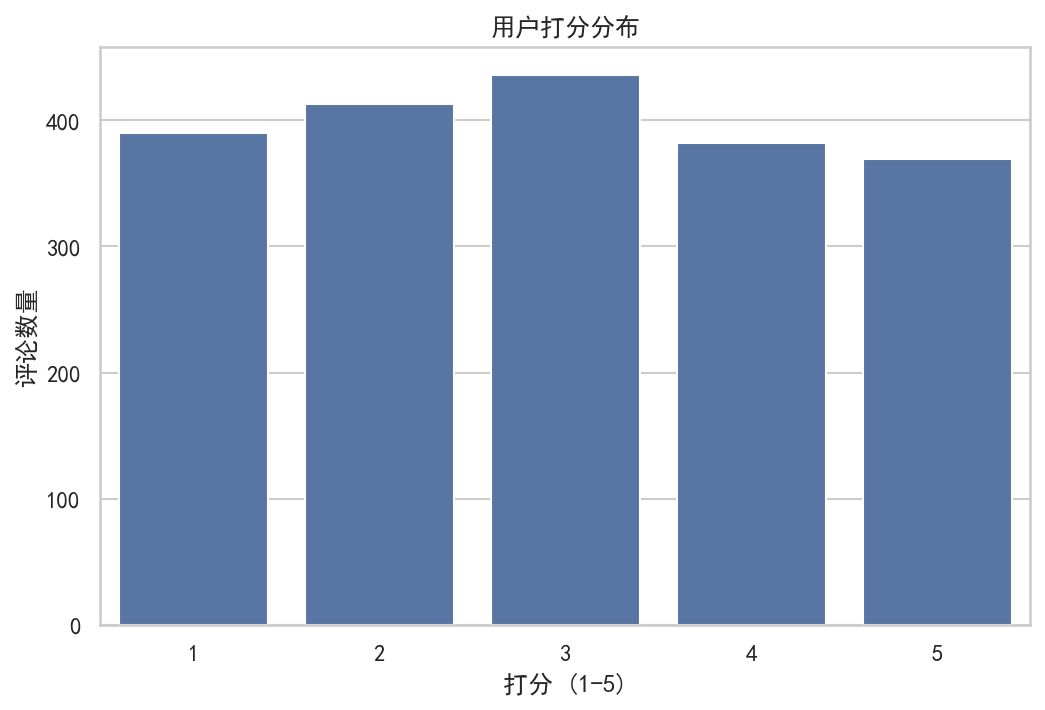

In [44]:
# 绘制一个柱状图 (或直方图)，展示用户打分 (`rating`) 的分布情况（即每个分数出现的次数）
# 图表标题为“用户打分分布”，x轴标签为“打分 (1-5)”，y轴标签为“评论数量”
# 确保中文显示正常
plt.figure(figsize=(8, 5), dpi=150)
sns.countplot(data=df, x="rating")
plt.title("用户打分分布")
plt.xlabel("打分 (1-5)")
plt.ylabel("评论数量")

plt.show()

<Figure size 1200x750 with 0 Axes>

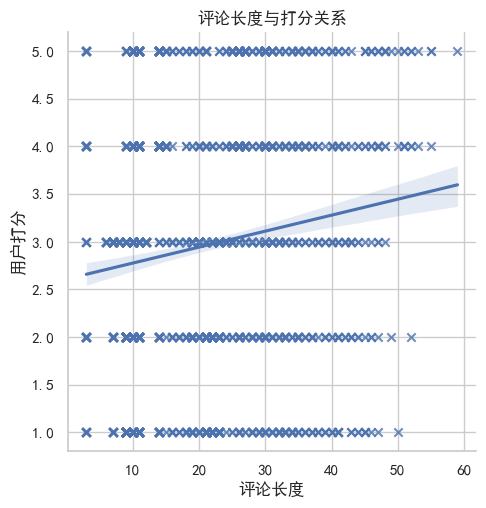

In [54]:
# 计算每条评论的文本长度 (字符数)，并将其作为一个新列 `review_length` 添加到数据集中
# 绘制一个散点图，横轴为 `review_length`，纵轴为 `rating`。
# 图表标题为“评论长度与打分关系”，x轴标签为“评论长度”，y轴标签为“用户打分”。
# 尝试使用 `seaborn` 绘制带有趋势线的散点图 (lmplot)。
df['review_length'] = df['review_text'].str.len().astype('int')
plt.figure(figsize=(8, 5), dpi=150)
sns.lmplot(data=df, x="review_length", y="rating", markers='x')
plt.title("评论长度与打分关系")
plt.xlabel("评论长度")
plt.ylabel("用户打分")

plt.show()

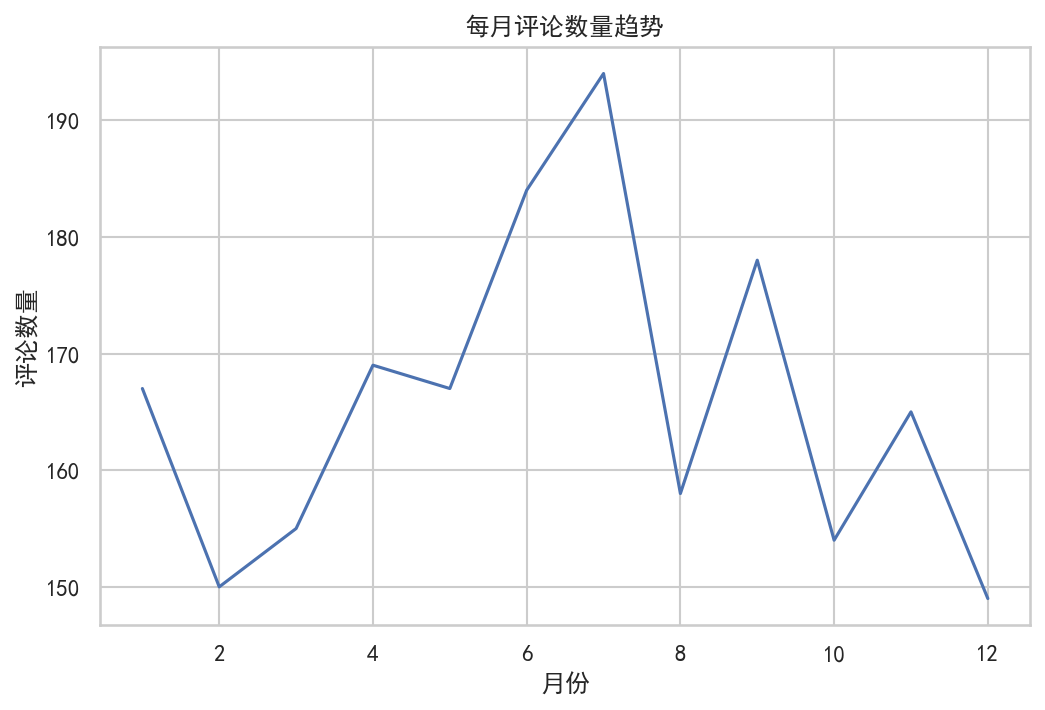

In [46]:
# 按月份统计评论数量，并绘制线图，展示每月评论数量的变化趋势。
# 图表标题为“每月评论数量趋势”，x轴标签为“月份”，y轴标签为“评论数量”
df['month'] = df['review_date'].dt.month
text_data = df.groupby("month", as_index=False)['review_text'].count()
text_data.head()


plt.figure(figsize=(8, 5), dpi=150)
sns.lineplot(x=text_data['month'], y=text_data['review_text'], legend=True)
plt.title("每月评论数量趋势")
plt.xlabel("月份")
plt.ylabel("评论数量")

plt.show()


4.  **机器学习入门：简单情感分类**：
    *   **任务一：定义情感标签**
        *   我们使用 `rating` 列来定义情感：
            *   `rating` >= 4 视为“积极评论” (Positive)
            *   `rating` <= 2 视为“消极评论” (Negative)
            *   `rating` == 3 视为“中性评论” (Neutral)
        *   为数据集添加一个新的列 `sentiment_label`，存储上述情感标签 (`'Positive'`, `'Negative'`, `'Neutral'`)。
    *   **任务二：文本数据预处理 (TF-IDF 特征提取)**
        *   我们将使用 `review_text` 列作为机器学习模型的输入特征。
        *   导入 `TfidfVectorizer`。
        *   使用 `TfidfVectorizer` 将 `review_text` 转换为数值特征向量。考虑到是中文评论，请设置 `analyzer='char'` 和 `ngram_range=(1, 2)` (即使用1-gram和2-gram的字符特征)，这样可以更好地捕捉中文文本的局部特征，而无需专门的分词器。
        *   **说明**： TF-IDF（Term Frequency-Inverse Document Frequency）是一种统计方法，用于评估一个词对一个文档集或一个语料库中的一个文档的重要程度。
    *   **任务三：数据集划分**
        *   将特征 (`X`，即 TF-IDF 向量) 和标签 (`y`，即 `sentiment_label`) 划分为训练集和测试集。使用 `train_test_split`，设置 `test_size=0.2` (20% 作为测试集)，`random_state=42`。
    *   **任务四：模型训练与评估**
        *   导入 `LogisticRegression` 模型。
        *   使用训练集 (`X_train`, `y_train`) 训练 `LogisticRegression` 模型。
        *   使用测试集 (`X_test`) 进行预测 (`y_pred`)。
        *   导入 `classification_report` 和 `accuracy_score`。
        *   打印模型的分类报告和准确率，评估模型性能。

In [47]:
# 我们使用 `rating` 列来定义情感：
#  `rating` >= 4 视为“积极评论” (Positive)
# `rating` <= 2 视为“消极评论” (Negative)
# `rating` == 3 视为“中性评论” (Neutral)

def motion(rating):
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"
    
df['sentiment_label'] = df['rating'].apply(motion)
df['sentiment_label'].head()

0    Negative
1    Positive
2    Negative
3     Neutral
4    Negative
Name: sentiment_label, dtype: object

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
# 使用 `review_text` 列作为机器学习模型的输入特征。
# 使用 `TfidfVectorizer` 将 `review_text` 转换为数值特征向量。考虑到是中文评论，请设置 `analyzer='char'` 和 `ngram_range=(1, 2)` (即使用1-gram和2-gram的字符特征)，这样可以更好地捕捉中文文本的局部特征，而无需专门的分词器。
data = df['review_text']
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(1, 2))
X = vectorizer.fit_transform(data)
y = df['sentiment_label']

#  将特征 (`X`，即 TF-IDF 向量) 和标签 (`y`，即 `sentiment_label`) 划分为训练集和测试集。使用 `train_test_split`，设置 `test_size=0.2` (20% 作为测试集)，`random_state=42`
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 导入 `LogisticRegression` 模型。
logic = LogisticRegression(random_state=42, max_iter=1000)
# 使用训练集 (`X_train`, `y_train`) 训练 `LogisticRegression` 模型
logic.fit(X=X_train, y=y_train)
# 使用测试集 (`X_test`) 进行预测 (`y_pred`)。
y_pred = logic.predict(X_test)

# 导入 `classification_report` 和 `accuracy_score`
print(
f"""
分类报告：{classification_report(y_test, y_pred)}
准确率：{accuracy_score(y_test, y_pred)}
"""
)



分类报告：              precision    recall  f1-score   support

    Negative       0.90      0.96      0.93       163
     Neutral       0.97      0.76      0.85        84
    Positive       0.92      0.97      0.94       151

    accuracy                           0.92       398
   macro avg       0.93      0.90      0.91       398
weighted avg       0.92      0.92      0.92       398

准确率：0.9195979899497487



In [ ]:
sklearn.feature_extraction.text.TfidfVectorizer (
    input='content', 
    encoding='utf-8', 
    decode_error='strict', 
    strip_accents=None, 
    lowercase=True, 
    preprocessor=None, 
    tokenizer=None, 
    analyzer='word', 
    stop_words=None, 
    token_pattern='(?u)\\b\\w\\w+\\b', 
    ngram_range=(1, 1), 
    max_df=1.0, 
    min_df=1, 
    max_features=None, 
    vocabulary=None, 
    binary=False, 
    dtype=<class 'numpy.float64'>, 
    norm='l2', 
    use_idf=True, 
    smooth_idf=True, 
    sublinear_tf=False
)





- **`input`**: 输入数据的类型，默认为 'content'（直接是字符串序列）。
- **`analyzer`**: 指定特征应该由“词”（'word'）还是“字符”（'char'）n-gram 组成。
    - `'word'`: 根据空格和 `token_pattern` 识别词语，并生成词语的 n-gram。
    - `'char'`: 根据每个字符生成 n-gram。
    - `'char_wb'`: 仅在单词边界处创建字符 n-gram。推荐用于不需要复杂分词的语言。
- **`ngram_range`**: 元组 `(min_n, max_n)`，表示要提取的 n-gram 的范围。例如 `(1, 2)` 表示提取 unigram (单个词/字符) 和 bigram (两个词/字符的组合)。
- **`stop_words`**: 要移除的停用词列表，或设置为 `'english'` 使用内置的英文停用词列表。对于中文，通常需要提供自定义的停用词列表。
- **`max_df`, `min_df`**: 用于过滤那些在太多或太少文档中出现的词，以去除低频或高频但无关紧要的词。
- **`max_features`**: 如果不是 `None`，则构建一个只包含前 `max_features` 个最频繁词（按文档频率计算）的词汇表。
- **`fit_transform(raw_documents)`**: 学习词汇表和 IDF 值，然后将 `raw_documents` 转换为 TF-IDF 矩阵。
- **`transform(raw_documents)`**: 使用已学习的词汇表和 IDF 值，将 `raw_documents` 转换为 TF-IDF 矩阵。


In [ ]:
# 题目 7：零售企业的数据分析

你是一名零售企业的数据分析师，现在有一份包含客户购物行为的数据集(customer_transactions.csv)。数据集模拟了客户交易情况，包含了以下字段：

- TransactionID: 交易ID (int)
- CustomerID: 客户ID (int)
- TransactionDate: 交易日期 (str, 格式可能混杂 "YYYY-MM-DD" 和 "MM/DD/YYYY")
- ProductCategory: 产品类别 (str, 可能有缺失值)
- Quantity: 购买数量 (int)
- UnitPrice: 商品单价 (float)
- TotalPrice: 总价格 (float, 可能有计算错误或缺失)
- PaymentMethod: 支付方式 (str, 如 'Credit Card', 'Cash', 'E-wallet')
- Region: 客户所在地区 (str, 可能有多种表示方式，如 'North', 'Northern', 'South', 'Southern')

你的任务是使用 Python (Pandas, Matplotlib, Seaborn) 完成以下数据处理、分析和可视化任务：

In [21]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 生成模拟数据
np.random.seed(42)
num_transactions = 1000

data = {
    'TransactionID': range(1, num_transactions + 1),
    'CustomerID': np.random.randint(100, 500, num_transactions),
    'TransactionDate': [
        (datetime(2023, 1, 1) + timedelta(days=np.random.randint(0, 364))).strftime("%Y-%m-%d")
        if np.random.rand() > 0.3 else
        (datetime(2023, 1, 1) + timedelta(days=np.random.randint(0, 364))).strftime("%m/%d/%Y")
        for _ in range(num_transactions)
    ],
    'ProductCategory': np.random.choice(['Electronics', 'Apparel', 'Food', 'Books', 'Home Goods', np.nan], num_transactions, p=[0.2, 0.25, 0.2, 0.15, 0.15, 0.05]),
    'Quantity': np.random.randint(1, 10, num_transactions),
    'UnitPrice': np.round(np.random.uniform(5, 500, num_transactions), 2),
    'PaymentMethod': np.random.choice(['Credit Card', 'Cash', 'E-wallet', 'Bank Transfer'], num_transactions, p=[0.4, 0.25, 0.2, 0.15]),
    'Region': np.random.choice(['North', 'South', 'East', 'West', 'Northern', 'Southern'], num_transactions, p=[0.2, 0.2, 0.2, 0.2, 0.1, 0.1])
}

df = pd.DataFrame(data)

# 引入一些缺失值和错误
df.loc[np.random.choice(df.index, 30, replace=False), 'UnitPrice'] = np.nan
df.loc[np.random.choice(df.index, 20, replace=False), 'Quantity'] = np.nan
df.loc[np.random.choice(df.index, 10, replace=False), 'TotalPrice'] = np.nan
df.loc[np.random.choice(df.index, 15, replace=False), 'TransactionDate'] = np.nan # 引入日期缺失

# 引入 TotalPrice 计算错误
error_indices = np.random.choice(df.index, 50, replace=False)
df.loc[error_indices, 'TotalPrice'] = df.loc[error_indices, 'Quantity'] * df.loc[error_indices, 'UnitPrice'] * np.random.uniform(0.5, 1.5, len(error_indices))
df.loc[df['Quantity'].isna() | df['UnitPrice'].isna(), 'TotalPrice'] = np.nan # 如果原数据就缺失，TotalPrice也设为缺失

# 保存到 CSV 文件
df.to_csv(r'csv\customer_transactions.csv', index=False)
print("模拟数据 'customer_transactions.csv' 已生成。")


模拟数据 'customer_transactions.csv' 已生成。



1.  **数据加载与初步查看：**
    *   加载 `customer_transactions.csv` 文件到 Pandas DataFrame。
    *   显示前5行数据，查看数据基本信息（`info()`）和统计摘要（`describe()`）。

2.  **数据清洗与预处理：**
    *   **日期格式统一：** 将 `TransactionDate` 列统一转换为 `YYYY-MM-DD` 格式的字符串，并进一步转换为 `datetime` 类型。处理转换过程中可能出现的缺失值，例如转换为 `NaT` (Not a Time)。
    *   **缺失值处理：**
        *   `ProductCategory` 的缺失值用众数填充。
        *   `Quantity` 和 `UnitPrice` 的缺失值，先检查这两列与 `TotalPrice` 的关系。如果 `Quantity` 或 `UnitPrice` 缺失，但 `TotalPrice` 不缺失，尝试利 `TotalPrice = Quantity * UnitPrice` 的关系进行反向填充。如果都无法推断，则用各自列的中位数进行填充。
        *   `TotalPrice` 的缺失值，如果 `Quantity` 和 `UnitPrice` 都不缺失，则重新计算填充；否则用该列的中位数填充。
        *   日期缺失值在转换为 `datetime` 时，会自动转换为 `NaT`，保留不变。
    *   **数据一致性：**
        *   统一 `Region` 列的表示方式，例如 'North' 和 'Northern' 都统一为 'North'，'South' 和 'Southern' 都统一为 'South'。
        *   确保 `TotalPrice` 的值是 `Quantity * UnitPrice` 的准确乘积。如果计算结果不符，则以 `Quantity * UnitPrice` 的结果为准进行修正，并删除原始 `TotalPrice` 为负数或零的行。

3.  **特征工程：**
    *   从 `TransactionDate` 中提取 `Year`, `Month`, `DayOfWeek` (星期几的名称，如 'Monday')，并创建为新列。
    *   计算每个 `CustomerID` 的 `PurchaseFrequency` (购买频率，即总交易次数) 和 `AverageOrderValue` (平均订单价值，即总价格/总交易次数)，将这些信息合并回原始 DataFrame。

4.  **数据可视化与分析：**
    *   **销售趋势分析：**
        *   绘制按季度汇总的总销售额（`TotalPrice`）折线图。要求：x轴显示季度，y轴显示总销售额，添加图标题、轴标签和图例。
        *   绘制不同 `PaymentMethod` 在各季度的销售额堆叠柱状图。
    *   **客户行为洞察：**
        *   使用 `sns.histplot` 或 `sns.kdeplot` 绘制 `AverageOrderValue` 的分布图，并用 `rug=True` 添加地毯图。
        *   绘制 `ProductCategory` 对 `TotalPrice` 的箱线图，并用 `sns.swarmplot` 添加原始数据点。
    *   **区域分析：**
        *   绘制各 `Region` 的总销售额柱状图，按销售额降序排列。
        *   使用热力图展示 `PaymentMethod` 与 `ProductCategory` 之间的交易计数关系。

In [46]:
#  加载 `customer_transactions.csv` 文件到 Pandas DataFrame。
#  显示前5行数据，查看数据基本信息（`info()`）和统计摘要（`describe()`）
df = pd.read_csv(r"csv\customer_transactions.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    1000 non-null   int64  
 1   CustomerID       1000 non-null   int64  
 2   TransactionDate  985 non-null    object 
 3   ProductCategory  957 non-null    object 
 4   Quantity         980 non-null    float64
 5   UnitPrice        970 non-null    float64
 6   PaymentMethod    1000 non-null   object 
 7   Region           1000 non-null   object 
 8   TotalPrice       49 non-null     float64
dtypes: float64(3), int64(2), object(4)
memory usage: 70.4+ KB
None
       TransactionID   CustomerID    Quantity   UnitPrice   TotalPrice
count    1000.000000  1000.000000  980.000000  970.000000    49.000000
mean      500.500000   301.511000    5.046939  247.325701  1183.891530
std       288.819436   114.355827    2.529063  141.200495  1050.219761
min         1.000000   100.000000    

In [47]:
# 将 `TransactionDate` 列统一转换为 `YYYY-MM-DD` 格式的字符串，并进一步转换为 `datetime` 类型。处理转换过程中可能出现的缺失值，例如转换为 `NaT` (Not a Time)。
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='mixed')
df['TransactionDate'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: TransactionDate
Non-Null Count  Dtype         
--------------  -----         
985 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.9 KB


In [48]:
# `ProductCategory` 的缺失值用众数填充
df['ProductCategory'] = df['ProductCategory'].fillna(df['ProductCategory'].mode()[0])

# `Quantity` 和 `UnitPrice` 的缺失值，先检查这两列与 `TotalPrice` 的关系。如果 `Quantity` 或 `UnitPrice` 缺失，但 `TotalPrice` 不缺失，尝试利 `TotalPrice = Quantity * UnitPrice` 的关系进行反向填充。如果都无法推断，则用各自列的中位数进行填充。
Quantity_median = df['Quantity'].median()
UnitPrice_median = df['UnitPrice'].median()

df.loc[(df['Quantity'].isna()) | (df['UnitPrice'].notna() ) & (df['TotalPrice'].notna()), "Quantity"] = df.loc[(df['Quantity'].isna()) | (df['UnitPrice'].notna() ) & (df['TotalPrice'].notna()), "TotalPrice"] / df.loc[(df['Quantity'].isna()) | (df['UnitPrice'].notna() ) & (df['TotalPrice'].notna()), "UnitPrice"]
df.loc[(df['Quantity'].notna()) | (df['UnitPrice'].isna() ) & (df['TotalPrice'].notna()), "UnitPrice"] = df.loc[(df['Quantity'].notna()) | (df['UnitPrice'].isna() ) & (df['TotalPrice'].notna()), "TotalPrice"] / df.loc[(df['Quantity'].notna()) | (df['UnitPrice'].isna() ) & (df['TotalPrice'].notna()), "Quantity"]
df['Quantity'] = df['Quantity'].fillna(Quantity_median)
df['UnitPrice'] = df['UnitPrice'].fillna(UnitPrice_median)

# `TotalPrice` 的缺失值，如果 `Quantity` 和 `UnitPrice` 都不缺失，则重新计算填充；否则用该列的中位数填充。
df.loc[(df['Quantity'].notna()) & (df['UnitPrice'].notna() ) & (df['TotalPrice'].isna()), "TotalPrice"] = df.loc[(df['Quantity'].notna()) & (df['UnitPrice'].notna() ) & (df['TotalPrice'].isna()), "Quantity"] * df.loc[(df['Quantity'].notna()) & (df['UnitPrice'].notna() ) & (df['TotalPrice'].isna()), "UnitPrice"]
df['TotalPrice'] = df['TotalPrice'].fillna(df['TotalPrice'].median())

df[['UnitPrice', 'Quantity', 'TotalPrice']].isna().sum()


UnitPrice     0
Quantity      0
TotalPrice    0
dtype: int64

In [49]:
# 统一 `Region` 列的表示方式，例如 'North' 和 'Northern' 都统一为 'North'，'South' 和 'Southern' 都统一为 'South'
df['Region'] = df['Region'].str.replace('Northern', 'North')
df['Region'] = df['Region'].str.replace('Southern', 'South')

# 删除原始 `TotalPrice` 为负数或零的行。
df = df[df['TotalPrice'] > 0]
# 确保 `TotalPrice` 的值是 `Quantity * UnitPrice` 的准确乘积。如果计算结果不符，则以 `Quantity * UnitPrice` 的结果为准进行修正
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    1000 non-null   int64         
 1   CustomerID       1000 non-null   int64         
 2   TransactionDate  985 non-null    datetime64[ns]
 3   ProductCategory  1000 non-null   object        
 4   Quantity         1000 non-null   float64       
 5   UnitPrice        1000 non-null   float64       
 6   PaymentMethod    1000 non-null   object        
 7   Region           1000 non-null   object        
 8   TotalPrice       1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 70.4+ KB


In [50]:
# 从 `TransactionDate` 中提取 `Year`, `Month`, `DayOfWeek` (星期几的名称，如 'Monday')，并创建为新列
df['Year'], df['Month'], df['DayOfWeek'] = df['TransactionDate'].dt.year, df['TransactionDate'].dt.month, df['TransactionDate'].dt.day_name()
print(df[['Year', 'Month', 'DayOfWeek']].info())

#  计算每个 `CustomerID` 的 `PurchaseFrequency` (购买频率，即总交易次数) 和 `AverageOrderValue` (平均订单价值，即总价格/总交易次数)，将这些信息合并回原始 DataFrame。
tmp_df = df.groupby('CustomerID')[['TransactionID', 'TotalPrice']].agg({'TransactionID':'count', 'TotalPrice':'sum'})
print(tmp_df.head())
tmp_df.columns = ['PurchaseFrequency', 'TotalPrice']
tmp_df['AverageOrderValue'] = tmp_df['TotalPrice'] / tmp_df['PurchaseFrequency']
df = df.merge(right=tmp_df, how='left', left_on="CustomerID", right_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       985 non-null    float64
 1   Month      985 non-null    float64
 2   DayOfWeek  985 non-null    object 
dtypes: float64(2), object(1)
memory usage: 23.6+ KB
None
            TransactionID   TotalPrice
CustomerID                            
100                     5  6058.875000
101                     3  4970.386890
102                     1  2181.195000
103                     2  2423.550000
104                     5  7271.157798
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      1000 non-null   int64         
 1   CustomerID         1000 non-null   int64         
 2   TransactionDate    985 non-null  

- TransactionID: 交易ID (int)
- CustomerID: 客户ID (int)
- TransactionDate: 交易日期 (str, 格式可能混杂 "YYYY-MM-DD" 和 "MM/DD/YYYY")
- ProductCategory: 产品类别 (str, 可能有缺失值)
- Quantity: 购买数量 (int)
- UnitPrice: 商品单价 (float)
- TotalPrice: 总价格 (float, 可能有计算错误或缺失)
- PaymentMethod: 支付方式 (str, 如 'Credit Card', 'Cash', 'E-wallet')
- Region: 客户所在地区 (str, 可能有多种表示方式，如 'North', 'Northern', 'South', 'Southern')


In [51]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

<Figure size 3000x4800 with 0 Axes>

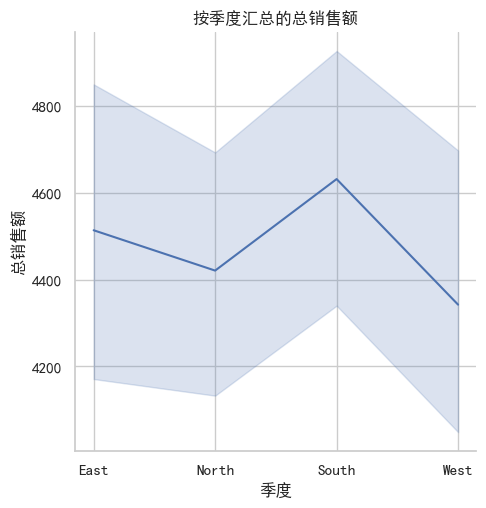

In [55]:
fig = plt.figure(figsize=(10, 16), dpi=300)
# 绘制按季度汇总的总销售额（`TotalPrice`）折线图。要求：x轴显示季度，y轴显示总销售额，添加图标题、轴标签和图例
sns.relplot(data=df, x='Region', y='TotalPrice_y', kind='line')
plt.title("按季度汇总的总销售额")
plt.xlabel('季度')
plt.ylabel('总销售额')
plt.show()

<Axes: xlabel='PaymentMethod,Region'>

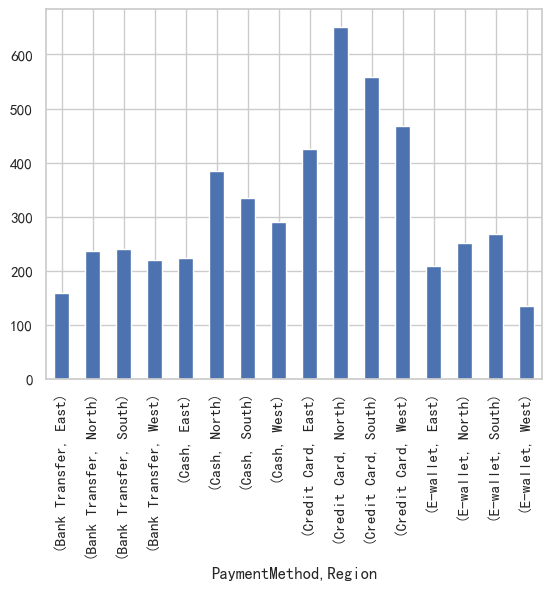

In [ ]:
# 绘制不同 `PaymentMethod` 在各季度的销售额堆叠柱状图。

# 使用 `sns.histplot` 或 `sns.kdeplot` 绘制 `AverageOrderValue` 的分布图，并用 `rug=True` 添加地毯图

# 绘制 `ProductCategory` 对 `TotalPrice` 的箱线图，并用 `sns.swarmplot` 添加原始数据点。

# 绘制各 `Region` 的总销售额柱状图，按销售额降序排列。

# 使用热力图展示 `PaymentMethod` 与 `ProductCategory` 之间的交易计数关系。


1.  **数据加载与初步查看：**
    *   加载 `customer_transactions.csv` 文件到 Pandas DataFrame。
    *   显示前5行数据，查看数据基本信息（`info()`）和统计摘要（`describe()`）。

2.  **数据清洗与预处理：**
    *   **日期格式统一：** 将 `TransactionDate` 列统一转换为 `YYYY-MM-DD` 格式的字符串，并进一步转换为 `datetime` 类型。处理转换过程中可能出现的缺失值，例如转换为 `NaT` (Not a Time)。
    *   **缺失值处理：**
        *   `ProductCategory` 的缺失值用众数填充。
        *   `Quantity` 和 `UnitPrice` 的缺失值，先检查这两列与 `TotalPrice` 的关系。如果 `Quantity` 或 `UnitPrice` 缺失，但 `TotalPrice` 不缺失，尝试利 `TotalPrice = Quantity * UnitPrice` 的关系进行反向填充。如果都无法推断，则用各自列的中位数进行填充。
        *   `TotalPrice` 的缺失值，如果 `Quantity` 和 `UnitPrice` 都不缺失，则重新计算填充；否则用该列的中位数填充。
        *   日期缺失值在转换为 `datetime` 时，会自动转换为 `NaT`，保留不变。
    *   **数据一致性：**
        *   统一 `Region` 列的表示方式，例如 'North' 和 'Northern' 都统一为 'North'，'South' 和 'Southern' 都统一为 'South'。
        *   确保 `TotalPrice` 的值是 `Quantity * UnitPrice` 的准确乘积。如果计算结果不符，则以 `Quantity * UnitPrice` 的结果为准进行修正，并删除原始 `TotalPrice` 为负数或零的行。

3.  **特征工程：**
    *   从 `TransactionDate` 中提取 `Year`, `Month`, `DayOfWeek` (星期几的名称，如 'Monday')，并创建为新列。
    *   计算每个 `CustomerID` 的 `PurchaseFrequency` (购买频率，即总交易次数) 和 `AverageOrderValue` (平均订单价值，即总价格/总交易次数)，将这些信息合并回原始 DataFrame。

4.  **数据可视化与分析：**
    *   **销售趋势分析：**
        *   绘制按季度汇总的总销售额（`TotalPrice`）折线图。要求：x轴显示季度，y轴显示总销售额，添加图标题、轴标签和图例。
        *   绘制不同 `PaymentMethod` 在各季度的销售额堆叠柱状图。
    *   **客户行为洞察：**
        *   使用 `sns.histplot` 或 `sns.kdeplot` 绘制 `AverageOrderValue` 的分布图，并用 `rug=True` 添加地毯图。
        *   绘制 `ProductCategory` 对 `TotalPrice` 的箱线图，并用 `sns.swarmplot` 添加原始数据点。
    *   **区域分析：**
        *   绘制各 `Region` 的总销售额柱状图，按销售额降序排列。
        *   使用热力图展示 `PaymentMethod` 与 `ProductCategory` 之间的交易计数关系。